Exercício 2 – Faça um regressão multinominal utilizando a base dados_lista_2_multinominal-1.csvDownload dados_lista_2_multinominal-1.csv

Determine o impacto das variáveis ses e write, no tipo de programa (prog) dos alunos da base. (prog ~ses + wrie)

Faça uma análise detalhada os odds em relação a probabilidade de cada tipo de programa, considerando todos os níveis.  

1 – Análise descritiva

2 – Faça o modelo de regressão

3 – Realize a análise dos pressupostos e validação do modelo

4 – Análise do Modelo

5 - Interpretação do ODDS

--- Distribuição da Variável Resposta (prog) ---
prog
academic    52.5
vocation    25.0
general     22.5
Name: proportion, dtype: float64

--- Tabela Cruzada: SES x PROG ---
prog    academic  general  vocation
ses                                
high          42        9         7
low           19       16        12
middle        44       20        31


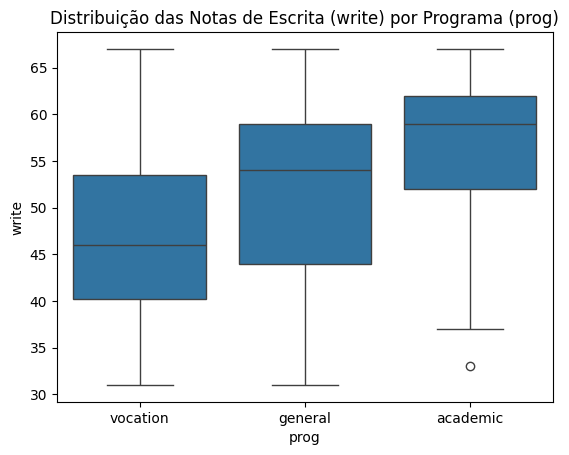

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregando os dados
df_prog = pd.read_csv('dados_lista_2_multinominal-1.csv')

# Exibe as proporções do Tipo de Programa (prog)
print("--- Distribuição da Variável Resposta (prog) ---")
print(df_prog['prog'].value_counts(normalize=True) * 100)

# Tabela cruzada entre SES (Nível Socioeconômico) e PROG
print("\n--- Tabela Cruzada: SES x PROG ---")
print(pd.crosstab(df_prog['ses'], df_prog['prog']))

# Boxplot para analisar a nota de escrita (write) em cada programa
sns.boxplot(x='prog', y='write', data=df_prog)
plt.title('Distribuição das Notas de Escrita (write) por Programa (prog)')
plt.show()

##### Análise Descritiva

variavel resposta = prog (categórica)

Podemos observar um desbalanceamento entre as categorias da variável resposta
Academic - 52,5%
Vocation - 25%
General - 22,5%

Análise da Tabela Cruzada:
Podemos observar que alunos do nível (ses) high tendem a se concentrar massivamente no programa Academic

Análise do Boxplot
A análise do boxplot demonstra que alunos matriculados no programa academic possuem notas de escrita, em mediana, notas consideravelmente superiores aos demais grupos.
Isso sugere que o desempenho acadêmico prévio em escrita é um forte discriminador para a escolha do programa



In [ ]:
categorias = df_prog['prog'].astype('category').cat.categories
dicionario_categorias = dict(enumerate(categorias))
print("--- Mapa de Categorias do Programa ---")
print(dicionario_categorias)

df_prog['prog_cod'] = df_prog['prog'].astype('category').cat.codes

modelo_multi = smf.mnlogit('prog_cod ~ C(ses) + write', data=df_prog).fit()

--- Mapa de Categorias do Programa ---
{0: 'academic', 1: 'general', 2: 'vocation'}
Optimization terminated successfully.
         Current function value: 0.899909
         Iterations 6


In [ ]:
X_vif = pd.get_dummies(df_prog[['ses', 'write']], drop_first=True)
X_vif = sm.add_constant(X_vif.astype(float))

vif_data = pd.DataFrame()
vif_data["Variável"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n--- Validação: Fator de Inflação da Variância (VIF) ---")
print(vif_data)


--- Validação: Fator de Inflação da Variância (VIF) ---
     Variável        VIF
0       const  40.185326
1       write   1.050453
2     ses_low   1.444182
3  ses_middle   1.431506


##### Análise dos pressupostos

1 - Ausência de Multicolinearidade: O teste resultou valores aceitaveis, abaixo do limite crítico, afirmando que não há colinearidade entre nota de escrita e nível socioeconomico

In [7]:
# 4. Sumário do Modelo
print("\n--- Sumário do Modelo Multinomial ---")
print(modelo_multi.summary())


--- Sumário do Modelo Multinomial ---
                          MNLogit Regression Results                          
Dep. Variable:               prog_cod   No. Observations:                  200
Model:                        MNLogit   Df Residuals:                      192
Method:                           MLE   Df Model:                            6
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.1182
Time:                        19:29:51   Log-Likelihood:                -179.98
converged:                       True   LL-Null:                       -204.10
Covariance Type:            nonrobust   LLR p-value:                 1.063e-08
      prog_cod=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.6894      1.227      1.377      0.169      -0.715       4.094
C(ses)[T.low]        1.1628      0.514      2.261      0.024       0.155  

#### Análise do Modelo
LLR p-value < 0.001 → o modelo como um todo é estatisticamente significativo.

cerca de 11,8% da variação nas probabilidades das categorias de prog_cod é explicada pelo modelo.

In [8]:
# 5. Calculando a Razão de Chances Relativas (Relative Risk Ratios)
print("\n--- Razão de Chances (Odds Ratios) ---")
odds_multi = np.exp(modelo_multi.params)
print(odds_multi)


--- Razão de Chances (Odds Ratios) ---
                         0          1
Intercept         5.415982  69.098280
C(ses)[T.low]     3.198980   2.671581
C(ses)[T.middle]  1.876749   3.575351
write             0.943718   0.892613


#### Interpretação ODDS

Impacto de write

Mantendo o impacto socioeconomico constante, para cada 1 ponto a mais na nota, as chances do aluno escolher o programa General em detrimento do Academic são multiplicadas por 0,94, ou seja, redução de 5,7% nas chances

Para Vocation, a cada 1 ponto, a escrita multiplica a chance de escolha por 0,89, uma redução de 10% em relação ao Academic


Impacto ses

Um aluno com status socioeconomico Low, possui 3,19 vezes mais chances de escolher o programa General e 2,67 vezes mais chances de escolher o programa Vocation que o Academic, quando comparado a Alunos High

Um aluno com status socioeconômico Middle possui 1,87 vezes mais chances de escolher o programa General e 3,57 vezes mais chances de escolher o programa Vocation do que o Academic, quando comparado a um aluno de status High.